In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:
df = pd.read_csv('social_media_addiction.csv')
def cls_age(i):
    if i < 26.5:
        return 'Plus Jeune'
    else:
        return 'Adulte'
df['Classe_age'] = df['Age'].apply(cls_age)

In [77]:
p_jeune = df[df['Classe_age'] == 'Plus Jeune']
adulte = df[df['Classe_age'] == 'Adulte']

In [78]:
p_jeune.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 0 to 19
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   User_ID                     11 non-null     int64 
 1   Age                         11 non-null     int64 
 2   Gender                      11 non-null     object
 3   Platform                    11 non-null     object
 4   Daily_Usage_Time_min        11 non-null     int64 
 5   Posts_Per_Day               11 non-null     int64 
 6   Likes_Received_Daily        11 non-null     int64 
 7   Comments_Received_Daily     11 non-null     int64 
 8   Messages_Sent_Daily         11 non-null     int64 
 9   Scroll_Rate_ppm             11 non-null     int64 
 10  Addiction_Level             11 non-null     object
 11  Emotional_State_Post_Usage  11 non-null     object
 12  Productivity_Loss_Score     11 non-null     int64 
 13  Mental_Health_Index         11 non-null     int64 
 14  F

In [79]:
#les niveaux d'addiction élevés (high/severe) sont associés à des états émotionnels plus négatifs ou plus intenses (comme anxious, depressed
#overwhelmed, stressed).
#On remarque aussi que ces cas sont plus fréquents chez les plus jeunes
add_lvl = (
    p_jeune
    .groupby(['Emotional_State_Post_Usage','Addiction_Level'])
    .size()
    .sort_values(ascending = False)
)
add_lvl

Emotional_State_Post_Usage  Addiction_Level
Angry                       Moderate           1
Anxious                     High               1
Bored                       Severe             1
Curious                     Moderate           1
Depressed                   Severe             1
Drained                     Severe             1
Envious                     High               1
Insecure                    High               1
Lonely                      High               1
Overwhelmed                 High               1
Stressed                    High               1
dtype: int64

In [80]:
p_jeune['Emotional_State_Post_Usage'].unique()

array(['Anxious', 'Depressed', 'Stressed', 'Bored', 'Envious', 'Lonely',
       'Angry', 'Curious', 'Drained', 'Overwhelmed', 'Insecure'],
      dtype=object)

In [81]:
adulte

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3,Adulte
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5,Adulte
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4,Adulte
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2,Adulte
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3,Adulte
12,1013,33,Female,LinkedIn,20,0,1,0,5,5,Low,Neutral,1,90,2,Adulte
15,1016,27,Male,Instagram,110,2,75,10,25,35,Moderate,Anxious,4,60,6,Adulte
16,1017,38,Female,Facebook,40,1,20,5,15,10,Low,Connected,2,80,3,Adulte
18,1019,30,Male,YouTube,130,0,15,2,0,10,Moderate,Relaxed,4,70,4,Adulte


In [82]:
#ici nous faison la même analyse chez les adultes et nous pouvons remarquer qu'il y a une grand réduction des cas élevés
#avec des niveaux d'addictions plus baisses, nous pouvons abserver la presque absence des cas émotionels négatifs
add_lvl_ = (
    adulte
    .groupby(['Emotional_State_Post_Usage','Addiction_Level'])
    .size()
    .sort_values(ascending = False)
)
add_lvl_

Emotional_State_Post_Usage  Addiction_Level
Neutral                     Low                2
Anxious                     Moderate           1
Happy                       Moderate           1
Connected                   Low                1
Inspired                    Low                1
Motivated                   Low                1
Neutral                     Moderate           1
Relaxed                     Moderate           1
dtype: int64

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   User_ID                     20 non-null     int64 
 1   Age                         20 non-null     int64 
 2   Gender                      20 non-null     object
 3   Platform                    20 non-null     object
 4   Daily_Usage_Time_min        20 non-null     int64 
 5   Posts_Per_Day               20 non-null     int64 
 6   Likes_Received_Daily        20 non-null     int64 
 7   Comments_Received_Daily     20 non-null     int64 
 8   Messages_Sent_Daily         20 non-null     int64 
 9   Scroll_Rate_ppm             20 non-null     int64 
 10  Addiction_Level             20 non-null     object
 11  Emotional_State_Post_Usage  20 non-null     object
 12  Productivity_Loss_Score     20 non-null     int64 
 13  Mental_Health_Index         20 non-null     int64 
 

In [84]:
df['Interactions'] = df['Posts_Per_Day'] + df['Likes_Received_Daily'] + df['Comments_Received_Daily'] + df['Messages_Sent_Daily']

In [85]:
df

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions
0,1001,23,Female,Instagram,145,3,120,25,45,40,High,Anxious,7,45,8,Plus Jeune,193
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9,Plus Jeune,61
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3,Adulte,22
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5,Adulte,62
4,1005,21,Non-binary,Twitter,180,15,200,60,50,55,High,Stressed,8,40,7,Plus Jeune,325
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4,Plus Jeune,11
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4,Adulte,89
7,1008,22,Male,TikTok,165,5,90,12,35,70,High,Envious,6,50,8,Plus Jeune,142
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2,Adulte,7
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3,Adulte,29


In [86]:
df['Interactions'].std()

np.float64(107.08573790733243)

<function matplotlib.pyplot.show(close=None, block=None)>

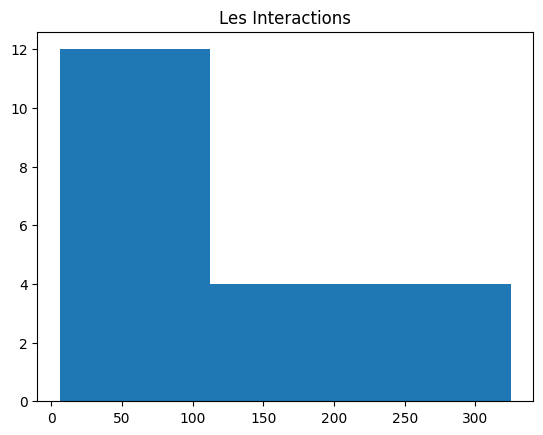

In [87]:
plt.hist(df['Interactions'], bins = 3)
plt.title('Les Interactions')
plt.show

In [91]:
df[(df['Interactions'] > 212.66) & (df['Interactions'] < 319)]

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions
11,1012,26,Male,Twitter,120,10,150,45,25,50,Moderate,Angry,5,55,6,Plus Jeune,230
17,1018,22,Non-binary,Discord,200,0,5,2,300,20,High,Overwhelmed,8,45,7,Plus Jeune,307
19,1020,19,Female,Snapchat,175,12,100,25,150,50,High,Insecure,8,35,9,Plus Jeune,287


In [89]:
i

,User_ID,Age,Gender,Platform,Daily_Usage_Time_min,Posts_Per_Day,Likes_Received_Daily,Comments_Received_Daily,Messages_Sent_Daily,Scroll_Rate_ppm,Addiction_Level,Emotional_State_Post_Usage,Productivity_Loss_Score,Mental_Health_Index,FOMO_Score,Classe_age,Interactions
1,1002,19,Male,TikTok,210,1,45,5,10,85,Severe,Depressed,9,30,9,Plus Jeune,61
2,1003,28,Female,LinkedIn,45,0,5,2,15,10,Low,Motivated,2,80,3,Adulte,22
3,1004,35,Male,Facebook,90,2,30,10,20,25,Moderate,Neutral,4,65,5,Adulte,62
5,1006,25,Male,YouTube,240,0,10,1,0,10,Severe,Bored,9,35,4,Plus Jeune,11
6,1007,31,Female,Instagram,60,1,50,8,30,20,Moderate,Happy,3,75,4,Adulte,89
8,1009,29,Female,Pinterest,30,0,2,0,5,15,Low,Inspired,1,85,2,Adulte,7
9,1010,40,Male,Facebook,50,1,15,3,10,10,Low,Neutral,2,70,3,Adulte,29
13,1014,24,Male,Reddit,150,2,25,15,0,30,Moderate,Curious,5,60,5,Plus Jeune,42
16,1017,38,Female,Facebook,40,1,20,5,15,10,Low,Connected,2,80,3,Adulte,41
18,1019,30,Male,YouTube,130,0,15,2,0,10,Moderate,Relaxed,4,70,4,Adulte,17
